In [58]:
import pandas as pd 
df=pd.read_csv("Drug_Sales.csv")
df

,Drug Name,Manufacturer,Dosage Form,Strength,Package Size,Units Sold,Revenue,Sale Date,Region,Sales Representative,Customer Type
0,Drug B,Company W,Tablet,100 mg/ml,50 g,1500,43833,07-02-2024,South America,Susan Hernandez,Clinics
1,Drug B,Company X,Cream,500 mg,100 ml,1194,48717,08-08-2023,South America,Jackie Wagner,Clinics
2,Drug E,Company X,Capsule,50 mg,60,618,43833,15-06-2024,Africa,Mariah Mccoy,Hospitals
3,Drug E,Company X,Injection,10 mg,100 ml,1455,48717,15-07-2024,Asia,Courtney Doyle,Pharmacy
4,Drug C,Company V,Tablet,100 mg/ml,50 g,130,43833,13-08-2023,South America,Dawn Torres,Clinics
...,...,...,...,...,...,...,...,...,...,...,...
995,Drug B,Company X,Syrup,100 mg/ml,100 ml,359,48717,06-12-2023,North America,Molly Adams,Clinics
996,Drug E,Company Y,Cream,50 mg,100 ml,1502,43833,24-11-2023,Europe,Michele Vance,Clinics
997,Drug C,Company W,Tablet,250 mg,30,1552,48717,26-04-2024,Asia,John Anthony,Online Pharmacy
998,Drug C,Company W,Capsule,50 mg,10 ml,1152,43833,26-04-2024,North America,Joseph Smith,Clinics


In [60]:
print(df.info())
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Drug Name             1000 non-null   object
 1   Manufacturer          1000 non-null   object
 2   Dosage Form           1000 non-null   object
 3   Strength              1000 non-null   object
 4   Package Size          1000 non-null   object
 5   Units Sold            1000 non-null   int64 
 6   Revenue               1000 non-null   int64 
 7   Sale Date             1000 non-null   object
 8   Region                1000 non-null   object
 9   Sales Representative  1000 non-null   object
 10  Customer Type         1000 non-null   object
dtypes: int64(2), object(9)
memory usage: 86.1+ KB
None
(1000, 11)
Index(['Drug Name', 'Manufacturer', 'Dosage Form', 'Strength', 'Package Size',
       'Units Sold', 'Revenue', 'Sale Date', 'Region', 'Sales Representative',
       'Customer Ty

In [62]:
print(df.isnull().sum())

Drug Name               0
Manufacturer            0
Dosage Form             0
Strength                0
Package Size            0
Units Sold              0
Revenue                 0
Sale Date               0
Region                  0
Sales Representative    0
Customer Type           0
dtype: int64


In [64]:
#Top-Selling Medicines

top_medicines = df.groupby('Drug Name')['Units Sold'].sum().sort_values(ascending=False)
print(top_medicines)

Drug Name
Drug B    248571
Drug C    213028
Drug D    205269
Drug A    199922
Drug E    189619
Name: Units Sold, dtype: int64


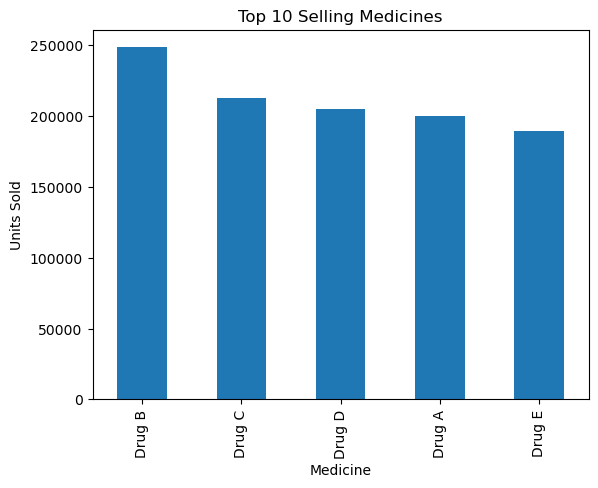

In [66]:
import matplotlib.pyplot as plt

top_medicines.plot(kind='bar')
plt.title("Top 10 Selling Medicines")
plt.xlabel("Medicine")
plt.ylabel("Units Sold")
plt.show()

In [68]:
revenue = df.groupby('Drug Name')['Revenue'].sum().sort_values(ascending=False)
print(revenue)

Drug Name
Drug B    10584888
Drug C     9464397
Drug D     8962698
Drug A     8631570
Drug E     8631447
Name: Revenue, dtype: int64


In [74]:
#Monthly Sales Growth

# Convert Sale Date to datetime
df['Sale Date'] = pd.to_datetime(df['Sale Date'], dayfirst=True)

# Create Month column
df['Month'] = df['Sale Date'].dt.month_name()
df

,Drug Name,Manufacturer,Dosage Form,Strength,Package Size,Units Sold,Revenue,Sale Date,Region,Sales Representative,Customer Type,Month
0,Drug B,Company W,Tablet,100 mg/ml,50 g,1500,43833,2024-02-07,South America,Susan Hernandez,Clinics,February
1,Drug B,Company X,Cream,500 mg,100 ml,1194,48717,2023-08-08,South America,Jackie Wagner,Clinics,August
2,Drug E,Company X,Capsule,50 mg,60,618,43833,2024-06-15,Africa,Mariah Mccoy,Hospitals,June
3,Drug E,Company X,Injection,10 mg,100 ml,1455,48717,2024-07-15,Asia,Courtney Doyle,Pharmacy,July
4,Drug C,Company V,Tablet,100 mg/ml,50 g,130,43833,2023-08-13,South America,Dawn Torres,Clinics,August
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Drug B,Company X,Syrup,100 mg/ml,100 ml,359,48717,2023-12-06,North America,Molly Adams,Clinics,December
996,Drug E,Company Y,Cream,50 mg,100 ml,1502,43833,2023-11-24,Europe,Michele Vance,Clinics,November
997,Drug C,Company W,Tablet,250 mg,30,1552,48717,2024-04-26,Asia,John Anthony,Online Pharmacy,April
998,Drug C,Company W,Capsule,50 mg,10 ml,1152,43833,2024-04-26,North America,Joseph Smith,Clinics,April


In [76]:
# Total units sold per month
monthly_units = df.groupby('Month')['Units Sold'].sum()
print(monthly_units)

Month
April         85144
August        98515
December     102765
February      74686
January       92953
July          90973
June          90179
March         85528
May           79457
November      97034
October       85601
September     73574
Name: Units Sold, dtype: int64


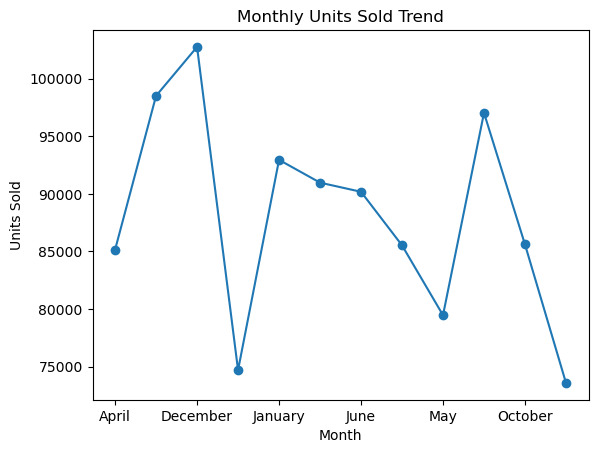

In [78]:
monthly_units.plot(kind='line', marker='o')
plt.title('Monthly Units Sold Trend')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.show()

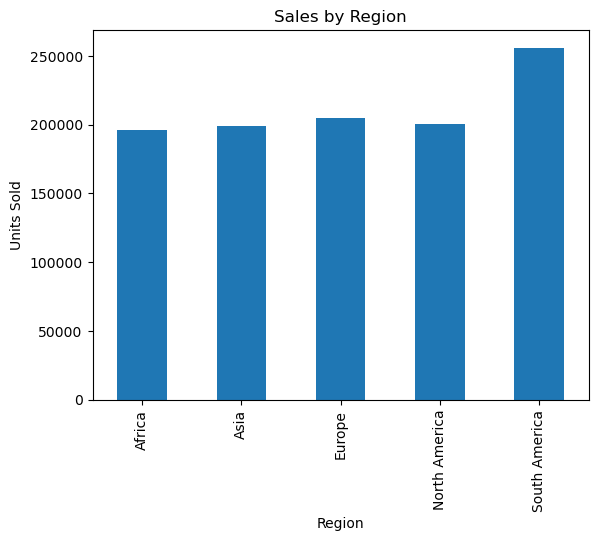

In [80]:
region_sales = df.groupby('Region')['Units Sold'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Units Sold')
plt.show()

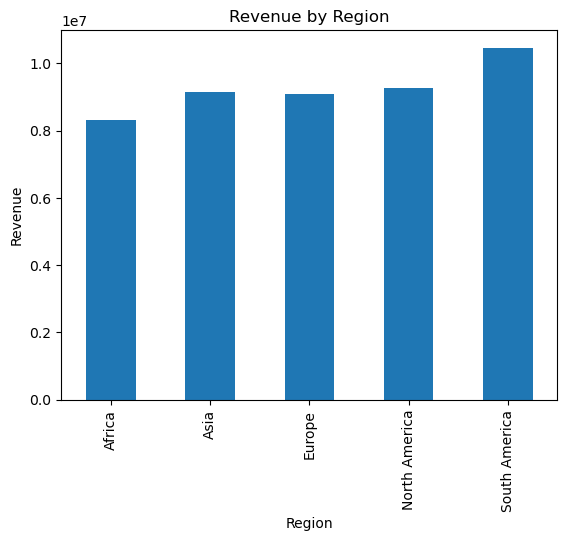

In [82]:
region_sales = df.groupby('Region')['Revenue'].sum()

region_sales.plot(kind='bar')
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.show()

In [84]:
revenue_by_drug = df.groupby('Drug Name')['Revenue'].sum().sort_values(ascending=False)
print(revenue_by_drug)

Drug Name
Drug B    10584888
Drug C     9464397
Drug D     8962698
Drug A     8631570
Drug E     8631447
Name: Revenue, dtype: int64


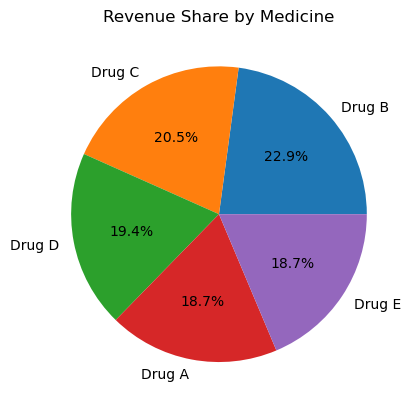

In [86]:
revenue_by_drug.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Share by Medicine')
plt.ylabel('')
plt.show()